In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../../data/raw/ecommerce_customer_churn_dataset.csv')
df.shape

(50000, 25)

---
## Linkedin post on kurtosis
beyond the needs of data validation: [link](https://www.linkedin.com/posts/shashankgarewal_machinelearning-datascience-mlengineering-share-7454159024763199488-o4fs)

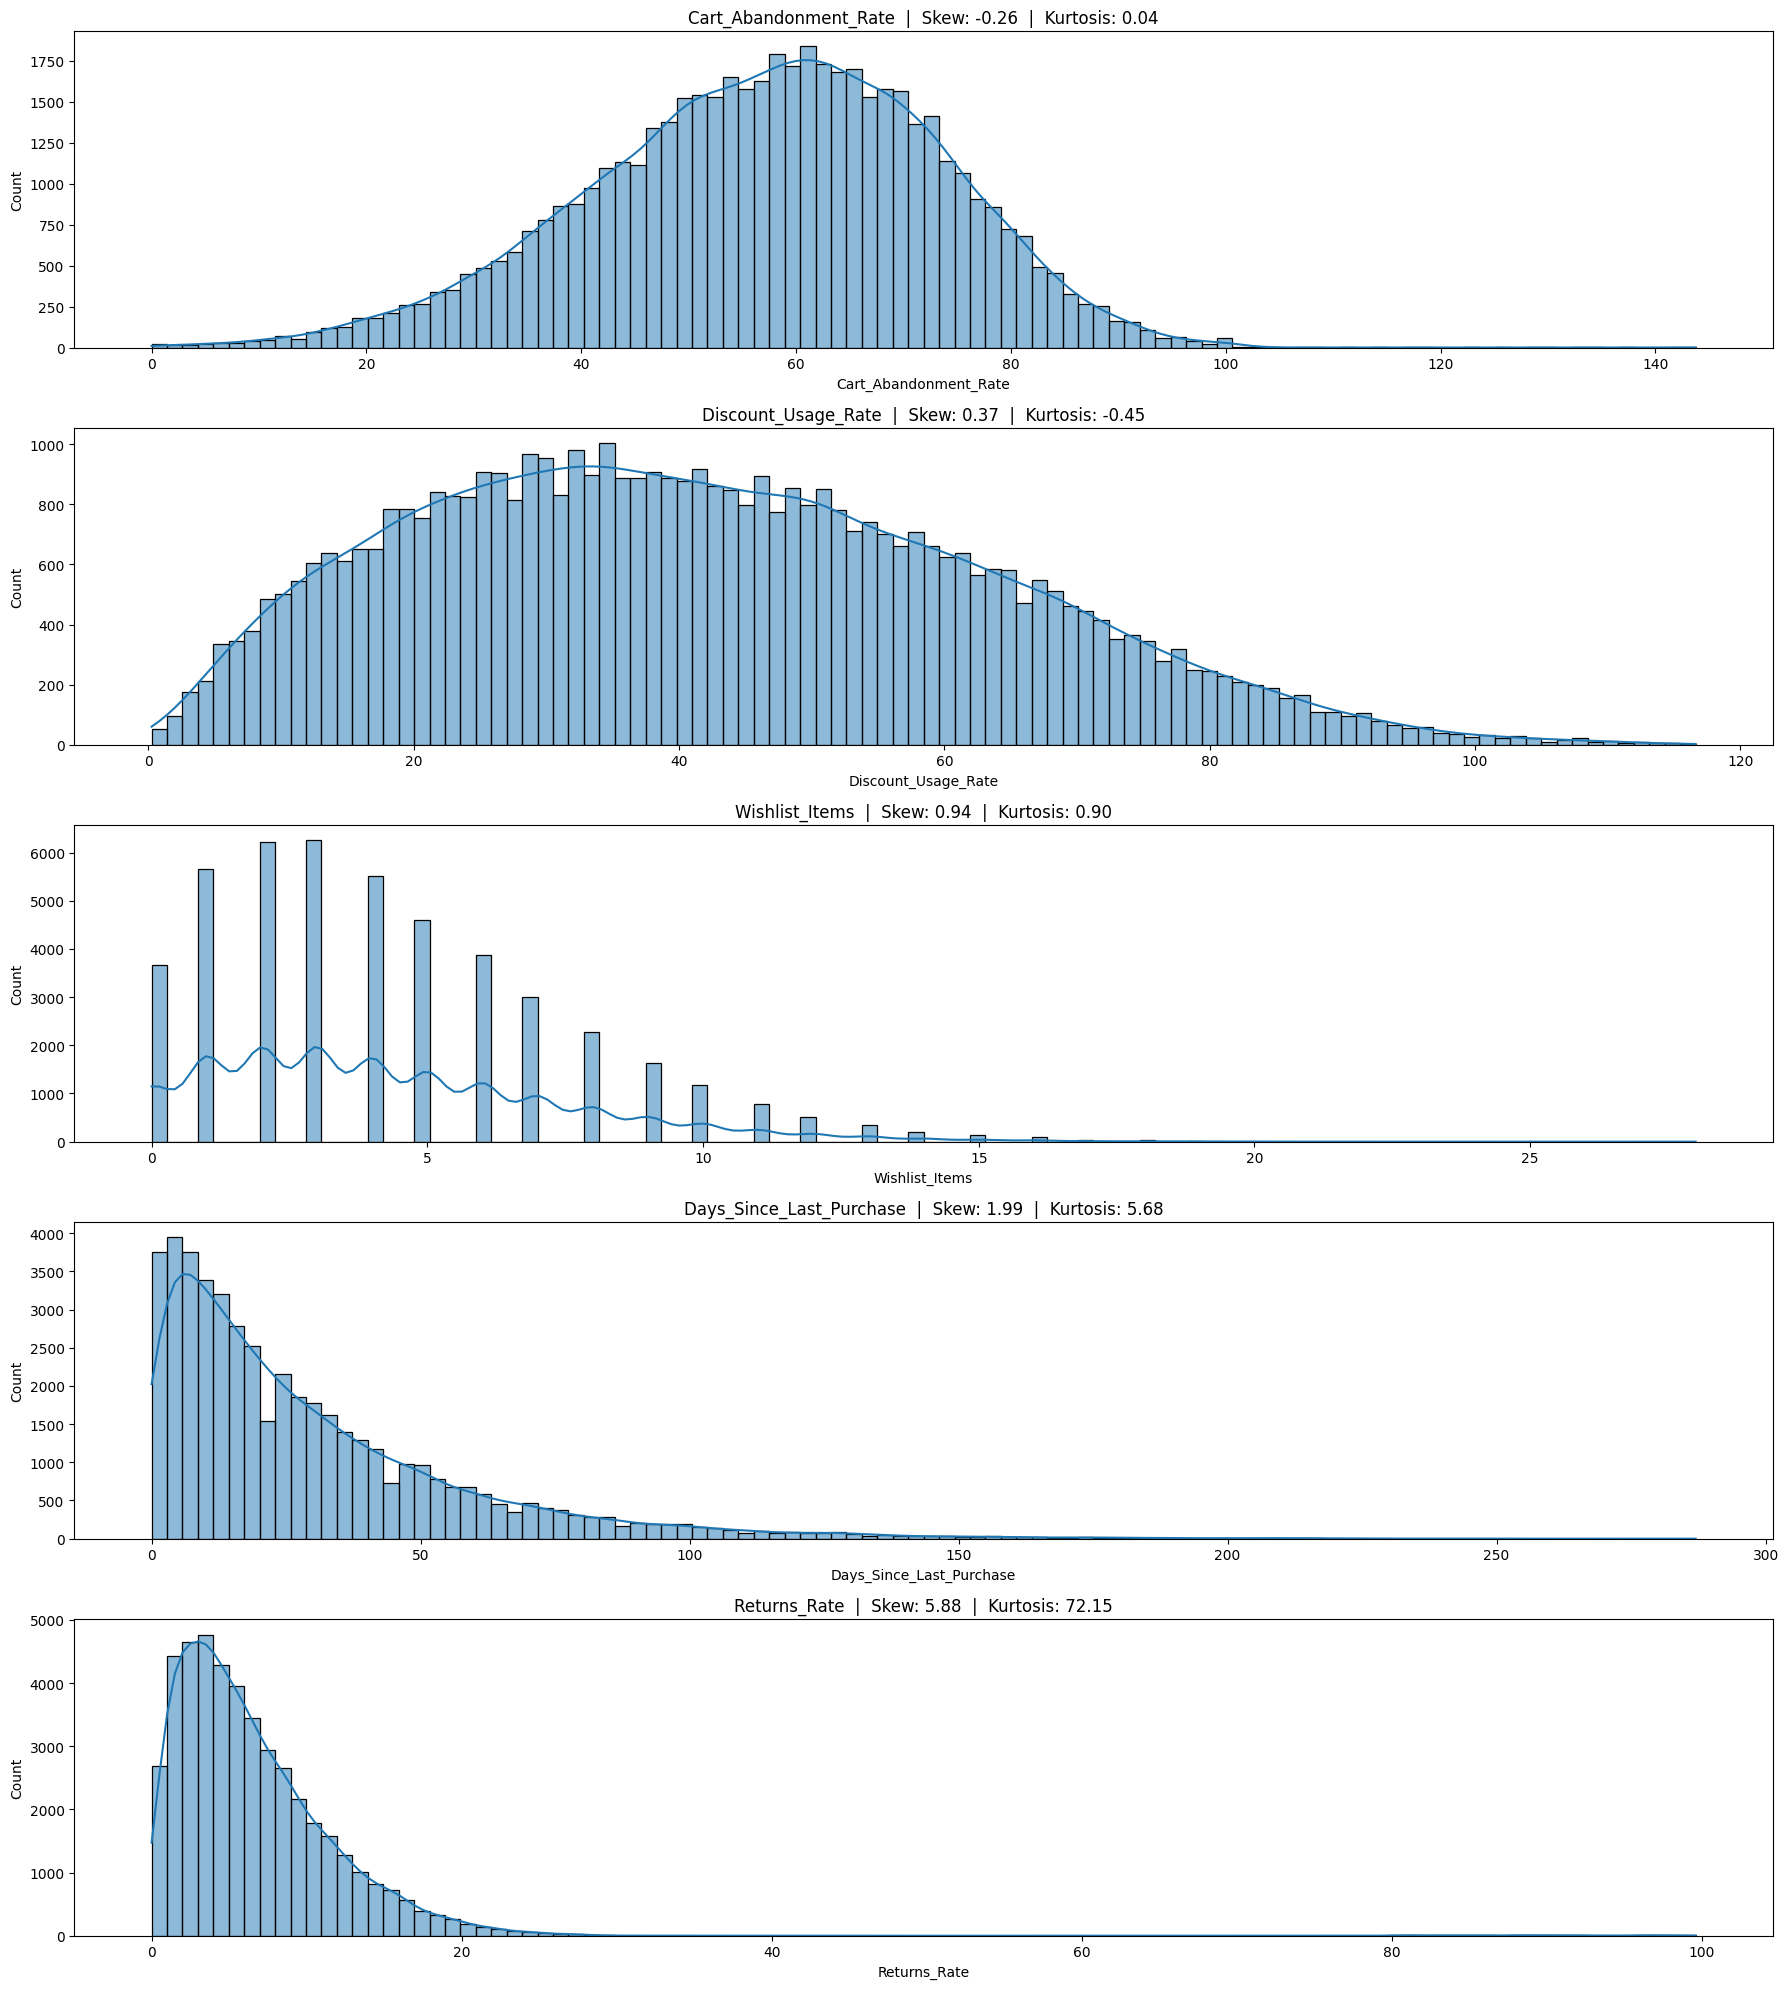

In [ ]:
# hist kde subplots 
import scipy.stats as stats

cols = [
    'Cart_Abandonment_Rate',
    'Discount_Usage_Rate',
    'Wishlist_Items',
    'Days_Since_Last_Purchase',
    'Returns_Rate'
]

plt.figure(figsize=(18, 20))

for i, col in enumerate(cols, 1):
    plt.subplot(5, 1, i)

    # compute skew & kurtosis
    skew_val = stats.skew(df[col].dropna())
    kurt_val = stats.kurtosis(df[col].dropna())

    sns.histplot(df[col], bins=100, kde=True)

    plt.title(f"{col}  |  Skew: {skew_val:.2f}  |  Kurtosis: {kurt_val:.2f}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


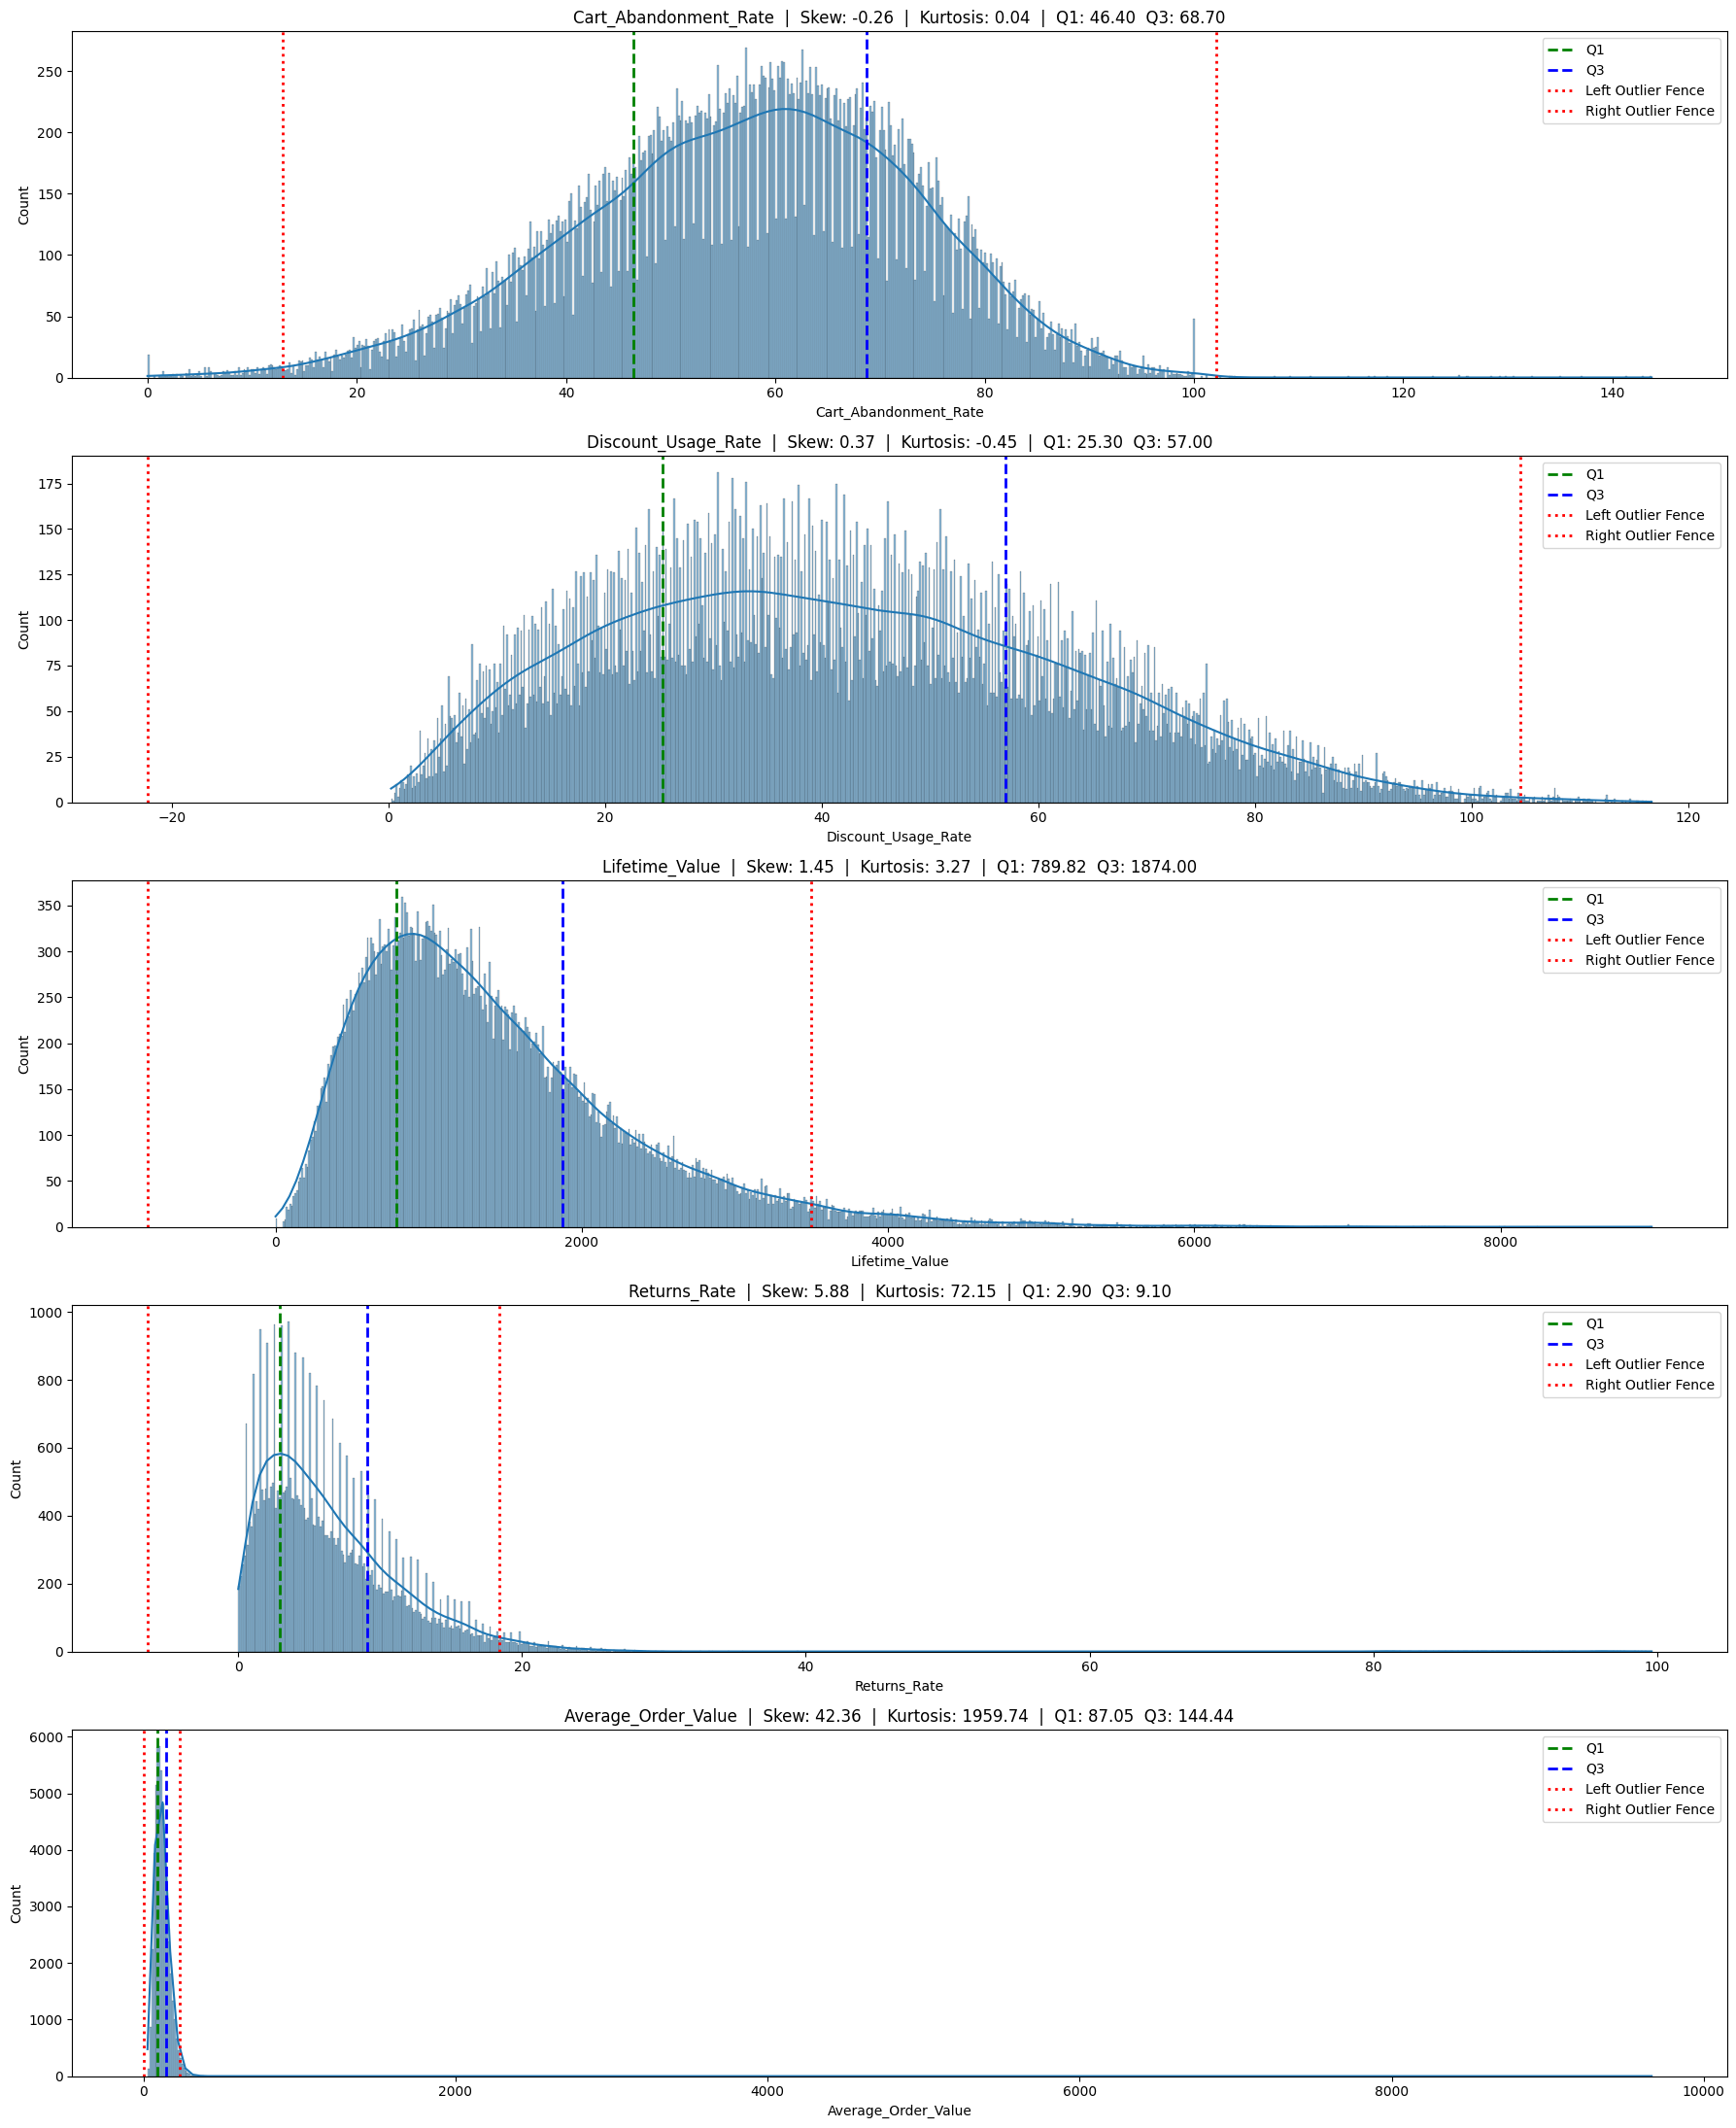

In [ ]:
# subplots with outliers thresholds
import scipy.stats as stats

cols = [
    'Cart_Abandonment_Rate',
    'Discount_Usage_Rate',
    'Lifetime_Value',
    'Returns_Rate',
    'Average_Order_Value'
]

plt.figure(figsize=(18, 22))

for i, col in enumerate(cols, 1):
    plt.subplot(5, 1, i)

    data = df[col].dropna()

    # Compute stats
    skew_val = stats.skew(data)
    kurt_val = stats.kurtosis(data)

    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1

    left_fence = q1 - 1.5 * iqr
    right_fence = q3 + 1.5 * iqr

    # Plot histogram + KDE
    sns.histplot(data, bins=800, kde=True)

    # Add Q1, Q3, and outlier fences
    plt.axvline(q1, color='green', linestyle='--', linewidth=2, label='Q1')
    plt.axvline(q3, color='blue', linestyle='--', linewidth=2, label='Q3')
    plt.axvline(left_fence, color='red', linestyle=':', linewidth=2, label='Left Outlier Fence')
    plt.axvline(right_fence, color='red', linestyle=':', linewidth=2, label='Right Outlier Fence')

    # Title with skew & kurtosis
    plt.title(
        f"{col}  |  Skew: {skew_val:.2f}  |  Kurtosis: {kurt_val:.2f}  "
        f"|  Q1: {q1:.2f}  Q3: {q3:.2f}"
    )

    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()

plt.tight_layout()
plt.show()

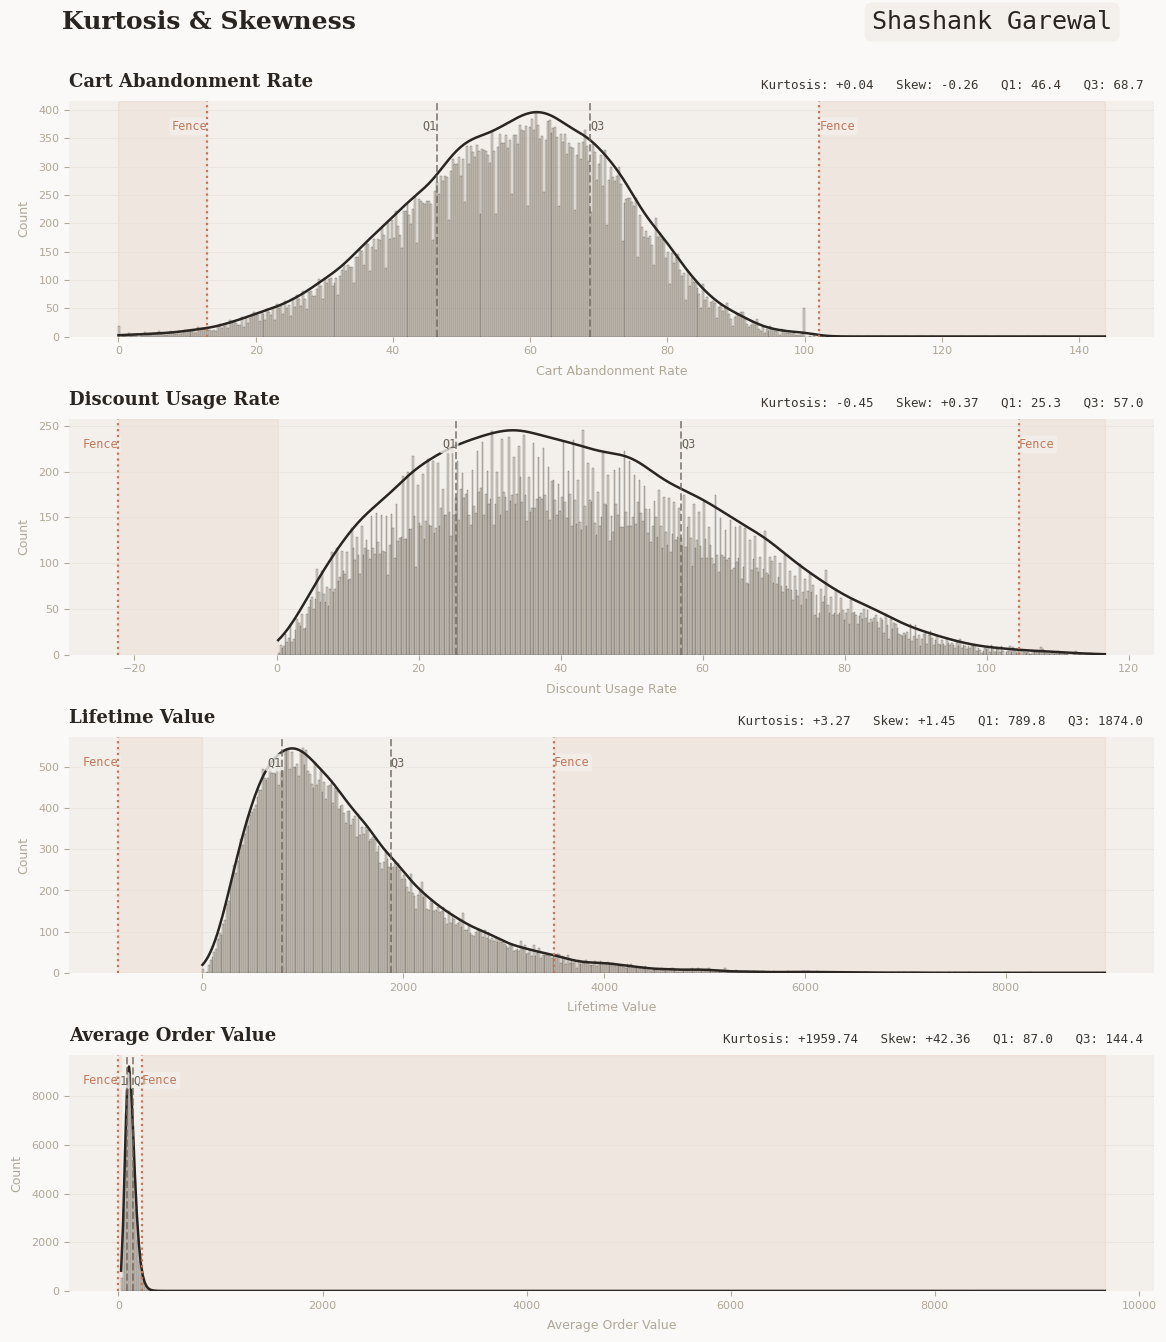

In [ ]:
# asthetic 
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


# ── Brand theme ───────────────────────────────────────────────
BG       = "#faf9f7"   # warm white
PANEL    = "#f3f0eb"   # soft panel
TEXT     = "#2a2520"   # dark brown
MUTED    = "#b0a898"   # grey
ACCENT   = "#c0785a"   # terracotta
FENCE    = "#c0785a"   # outlier fence
Q1_COL   = "#6b6259"   # dark grey
Q3_COL   = "#6b6259"
HIST_COL = "#c4baae"   # warm grey bars
KDE_COL  = "#2a2520"   # dark line


cols = [
    'Cart_Abandonment_Rate',
    'Discount_Usage_Rate',
    'Lifetime_Value',
    'Average_Order_Value'
]


fig, axes = plt.subplots(len(cols), 1, figsize=(14, 14))
fig.patch.set_facecolor(BG)
fig.subplots_adjust(hspace=0.35, top=0.91, bottom=0.06)

# ── Main topic title ─────────────────────────────────────────
fig.text(
    0.12, 0.975,
    "Kurtosis & Skewness",
    ha="left", va="top",
    fontsize=18, fontweight="bold",
    color=TEXT,
    fontfamily="serif"
)

fig.text(
    0.87, 0.975,
    "Shashank Garewal",
    ha="right", va="top",
    fontsize=18, color=TEXT,
    fontfamily="monospace",
    bbox=dict(boxstyle="round,pad=0.3",
              facecolor=PANEL, edgecolor="none", alpha=0.9)
)

for ax, col in zip(axes, cols):
    # ... your existing loop stays the same
    data = df[col].dropna()


    # ── Stats ──────────────────────────────────────────────────
    skew_val  = stats.skew(data)
    kurt_val  = stats.kurtosis(data)
    q1        = np.percentile(data, 25)
    q3        = np.percentile(data, 75)
    iqr       = q3 - q1
    left_fence  = q1 - 1.5 * iqr
    right_fence = q3 + 1.5 * iqr


    # ── Panel background ───────────────────────────────────────
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_visible(False)


    # ── Histogram + KDE ────────────────────────────────────────
    import seaborn as sns
    sns.histplot(
        data, bins=500, ax=ax,
        color=HIST_COL, alpha=0.6,
        line_kws={"linewidth": 0},
        kde=False
    )
    # KDE overlay
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 500)
    kde_vals = kde(x_range)
    # scale KDE to histogram height
    hist_counts, hist_bins = np.histogram(data, bins=500)
    scale = hist_counts.max() / kde_vals.max()
    ax.plot(x_range, kde_vals * scale, color=KDE_COL, linewidth=1.8, zorder=3)


    # ── Fence shading ──────────────────────────────────────────
    ax.axvspan(data.min(), left_fence,
               color=ACCENT, alpha=0.08, zorder=0)
    ax.axvspan(right_fence, data.max(),
               color=ACCENT, alpha=0.08, zorder=0)


    # ── Vertical lines ─────────────────────────────────────────
    ax.axvline(q1,          color=Q1_COL, linestyle="--",
               linewidth=1.4, alpha=0.7, zorder=4)
    ax.axvline(q3,          color=Q3_COL, linestyle="--",
               linewidth=1.4, alpha=0.7, zorder=4)
    ax.axvline(left_fence,  color=FENCE,  linestyle=":",
               linewidth=1.6, zorder=4)
    ax.axvline(right_fence, color=FENCE,  linestyle=":",
               linewidth=1.6, zorder=4)


    # ── Inline labels on lines ─────────────────────────────────
    ymax = ax.get_ylim()[1]
    for val, label, col_c, ha in [
        (q1,          "Q1",    Q1_COL, "right"),
        (q3,          "Q3",    Q3_COL, "left"),
        (left_fence,  "Fence", FENCE,  "right"),
        (right_fence, "Fence", FENCE,  "left"),
    ]:
        ax.text(val, ymax * 0.92, label,
                color=col_c, fontsize=8.5,
                ha=ha, va="top",
                fontfamily="monospace",
                bbox=dict(boxstyle="round,pad=0.2",
                          fc=PANEL, ec="none", alpha=0.8))


    # ── Title block ────────────────────────────────────────────
    col_display = col.replace("_", " ")
    ax.set_title(
        col_display,
        loc="left", pad=10,
        fontsize=13, fontweight="bold",
        color=TEXT, fontfamily="serif"
    )


    # ── Stats badge (top right) ────────────────────────────────
    badge = (
        f"Kurtosis: {kurt_val:+.2f}   "
        f"Skew: {skew_val:+.2f}   "
        f"Q1: {q1:.1f}   Q3: {q3:.1f}"
    )
    ax.text(
        0.99, 1.04, badge,
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=9, color="#3a3530",
        fontfamily="monospace"
    )


    # ── Axis styling ───────────────────────────────────────────
    ax.tick_params(colors=MUTED, labelsize=8)
    ax.set_xlabel(col_display, fontsize=9, color=MUTED, labelpad=6)
    ax.set_ylabel("Count", fontsize=9, color=MUTED, labelpad=6)
    ax.yaxis.grid(True, color="#e8e3dc", linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)


# ── Footer ─────────────────────────────────────────────────────
# fig.text(
#     0.9, 0.9,
#     "Shashank Garewal",
#     ha="right", va="top",
#     fontsize=9, color="#3a3530",
#     fontfamily="monospace"
# )


plt.savefig("kurtosis_linkedin.svg", format="svg", bbox_inches="tight", facecolor=BG)
plt.show()